In [1]:
import sys, torch

print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO CUDA")

Python exe: c:\Users\user\.conda\envs\CTIP_CLIP\python.exe
Torch version: 2.7.1+cu118
CUDA available: True
Torch CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import torch
from transformers import CLIPModel, AutoProcessor

MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
clip_model = CLIPModel.from_pretrained(
    MODEL_NAME,
    use_safetensors=True
).to(DEVICE)

clip_model.eval()

print("Loaded model on:", DEVICE)
print("Parameter device:", next(clip_model.parameters()).device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model on: cuda
Parameter device: cuda:0


In [3]:
from pathlib import Path

DATASET_DIR = Path(r"C:\COS30049 Assignment\Datasets\touching_plant")
CLASS_NAME = "touching_plant"
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

files = sorted([f for f in DATASET_DIR.iterdir() if f.is_file() and f.suffix.lower() in valid_ext])

for idx, f in enumerate(files, start=1):
    new_name = f"{CLASS_NAME}_{idx:04d}{f.suffix.lower()}"
    new_path = DATASET_DIR / new_name
    if f != new_path:
        f.rename(new_path)

print(f"Done. Renamed {len(files)} images in: {DATASET_DIR}")

Done. Renamed 17 images in: C:\COS30049 Assignment\Datasets\touching_plant


In [6]:
import json
from pathlib import Path

import torch
from PIL import Image
from tqdm import tqdm
from transformers import AutoProcessor, CLIPVisionModelWithProjection

DATASET_DIR = Path(r"C:\COS30049 Assignment\Datasets\touching_plant")
SAVE_DIR = Path(r"C:\COS30049 Assignment\artifacts")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

processor = AutoProcessor.from_pretrained(MODEL_NAME)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    MODEL_NAME,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

image_paths = sorted([p for p in DATASET_DIR.iterdir() if p.is_file() and p.suffix.lower() in valid_ext])

if len(image_paths) == 0:
    raise ValueError(f"No images found in {DATASET_DIR}")

print(f"Found {len(image_paths)} training images.")
print(f"Using device: {DEVICE}")

embeddings = []
kept_paths = []

with torch.no_grad():
    for img_path in tqdm(image_paths, desc="Extracting CLIP embeddings"):
        image = Image.open(img_path).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

        outputs = vision_model(pixel_values=pixel_values)
        image_features = outputs.image_embeds
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        embeddings.append(image_features.squeeze(0).cpu())
        kept_paths.append(str(img_path))

embeddings = torch.stack(embeddings)

prototype = embeddings.mean(dim=0)
prototype = prototype / prototype.norm()

similarities = torch.matmul(embeddings, prototype)

mean_sim = similarities.mean().item()
std_sim = similarities.std(unbiased=False).item()
threshold = max(0.0, mean_sim - 2 * std_sim)

torch.save(
    {
        "prototype": prototype,
        "threshold": threshold,
        "model_name": MODEL_NAME,
        "class_name": "touching_plant",
        "num_train_images": len(embeddings),
    },
    SAVE_DIR / "touching_plant_clip_prototype.pt"
)

with open(SAVE_DIR / "touching_plant_training_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "class_name": "touching_plant",
            "model_name": MODEL_NAME,
            "num_train_images": len(embeddings),
            "mean_similarity": mean_sim,
            "std_similarity": std_sim,
            "threshold": threshold,
            "image_paths_used": kept_paths,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Training finished.")
print("Mean similarity:", round(mean_sim, 4))
print("Std similarity :", round(std_sim, 4))
print("Threshold      :", round(threshold, 4))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

Found 17 training images.
Using device: cuda


Extracting CLIP embeddings: 100%|██████████| 17/17 [00:00<00:00, 83.11it/s]

Training finished.
Mean similarity: 0.8893
Std similarity : 0.026
Threshold      : 0.8372


In [7]:
import torch
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

MODEL_PATH = Path(r"C:\COS30049 Assignment\artifacts\touching_plant_clip_prototype.pt")
IMAGE_PATH = Path(r"C:\COS30049 Assignment\Datasets\touching_plant\touching_plant_0001.png")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]
threshold = saved["threshold"]
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

image = Image.open(IMAGE_PATH).convert("RGB")
pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

with torch.no_grad():
    outputs = vision_model(pixel_values=pixel_values)
    image_features = outputs.image_embeds
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

similarity = torch.matmul(image_features.cpu(), prototype).item()

print("Similarity:", round(similarity, 4))
print("Threshold :", round(threshold, 4))
print("Predicted :", "touching_plant" if similarity >= threshold else "not_touching_plant")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

Similarity: 0.9024
Threshold : 0.8372
Predicted : touching_plant


In [8]:
import torch
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

MODEL_PATH = Path(r"C:\COS30049 Assignment\artifacts\touching_plant_clip_prototype.pt")
IMAGE_PATH = Path(r"C:\COS30049 Assignment\hand-touching-monstera-leaf.jpg")  # change this

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]
threshold = saved["threshold"]
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

image = Image.open(IMAGE_PATH).convert("RGB")
pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

with torch.no_grad():
    outputs = vision_model(pixel_values=pixel_values)
    image_features = outputs.image_embeds
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

similarity = torch.matmul(image_features.cpu(), prototype).item()

print("Similarity:", round(similarity, 4))
print("Threshold :", round(threshold, 4))
print("Predicted :", "touching_plant" if similarity >= threshold else "not_touching_plant")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

Similarity: 0.9003
Threshold : 0.8372
Predicted : touching_plant


In [9]:
import torch
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

MODEL_PATH = Path(r"C:\COS30049 Assignment\artifacts\touching_plant_clip_prototype.pt")
TEST_DIR = Path(r"C:\COS30049 Assignment\TestImages")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]
threshold = saved["threshold"]
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

image_paths = sorted([p for p in TEST_DIR.iterdir() if p.is_file() and p.suffix.lower() in valid_ext])

if len(image_paths) == 0:
    raise ValueError(f"No images found in {TEST_DIR}")

results = []

with torch.no_grad():
    for img_path in image_paths:
        try:
            image = Image.open(img_path).convert("RGB")
            pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

            outputs = vision_model(pixel_values=pixel_values)
            image_features = outputs.image_embeds
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = torch.matmul(image_features.cpu(), prototype).item()
            pred = "touching_plant" if similarity >= threshold else "not_touching_plant"

            results.append((img_path.name, similarity, pred))
        except Exception as e:
            results.append((img_path.name, None, f"ERROR: {e}"))

for name, sim, pred in results:
    if sim is None:
        print(f"{name:35} -> {pred}")
    else:
        print(f"{name:35} -> similarity={sim:.4f} | {pred}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

hand-touching-monstera-leaf.jpg     -> similarity=0.9003 | touching_plant
Screenshot 2026-04-03 230247.png    -> similarity=0.8564 | touching_plant
Screenshot 2026-04-03 230511.png    -> similarity=0.8139 | not_touching_plant
Screenshot 2026-04-03 230516.png    -> similarity=0.7684 | not_touching_plant
Screenshot 2026-04-03 230521.png    -> similarity=0.8667 | touching_plant
Screenshot 2026-04-03 230536.png    -> similarity=0.7894 | not_touching_plant
Screenshot 2026-04-03 230557.png    -> similarity=0.8207 | not_touching_plant
Screenshot 2026-04-03 230611.png    -> similarity=0.3804 | not_touching_plant
Screenshot 2026-04-03 230620.png    -> similarity=0.6717 | not_touching_plant
Screenshot 2026-04-03 230625.png    -> similarity=0.7731 | not_touching_plant
Screenshot 2026-04-03 230631.png    -> similarity=0.7703 | not_touching_plant


In [10]:
import csv
from pathlib import Path

CSV_PATH = Path(r"C:\COS30049 Assignment\artifacts\batch_test_results.csv")

with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "similarity", "prediction"])
    for name, sim, pred in results:
        writer.writerow([name, sim, pred])

print("Saved:", CSV_PATH)

Saved: C:\COS30049 Assignment\artifacts\batch_test_results.csv


In [13]:
import torch
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

MODEL_PATH = Path(r"C:\COS30049 Assignment\artifacts\touching_plant_clip_prototype.pt")
BASE_TEST_DIR = Path(r"C:\COS30049 Assignment\TestImages")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]
threshold = saved["threshold"]
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

folders = {
    "touching_plant": 1,
    "not_touching_plant": 0,
}

total = 0
correct = 0

with torch.no_grad():
    for folder_name, true_label in folders.items():
        folder = BASE_TEST_DIR / folder_name
        image_paths = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_ext]

        for img_path in image_paths:
            image = Image.open(img_path).convert("RGB")
            pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

            outputs = vision_model(pixel_values=pixel_values)
            image_features = outputs.image_embeds
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = torch.matmul(image_features.cpu(), prototype).item()
            pred_label = 1 if similarity >= threshold else 0

            total += 1
            correct += int(pred_label == true_label)

print("Total images:", total)
print("Correct     :", correct)
print("Accuracy    :", round(correct / total, 4) if total > 0 else 0.0)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

Total images: 11
Correct     : 6
Accuracy    : 0.5455


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

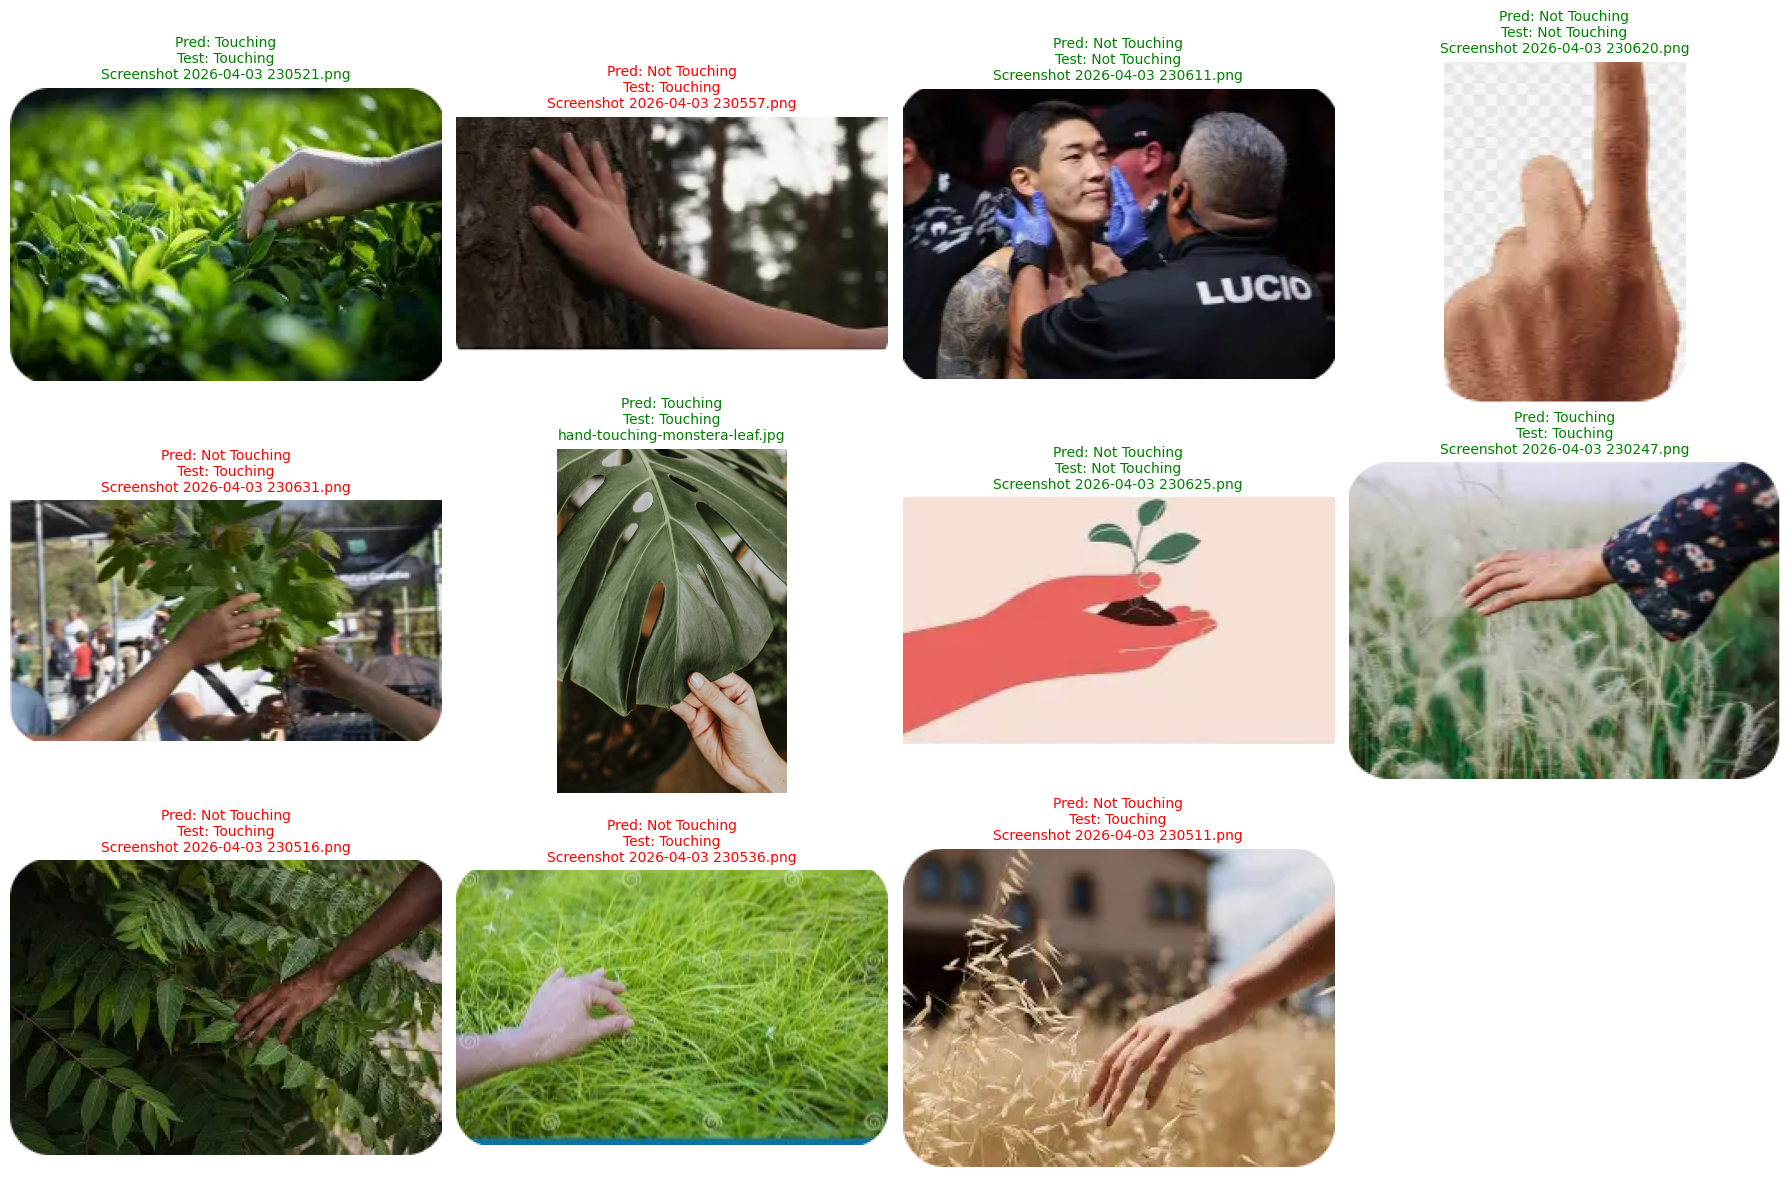

In [14]:
import random
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

# =========================
# CONFIG
# =========================
MODEL_PATH = Path(r"C:\COS30049 Assignment\artifacts\touching_plant_clip_prototype.pt")
BASE_TEST_DIR = Path(r"C:\COS30049 Assignment\TestImages")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Ground-truth folders
folder_to_label = {
    "touching_plant": "Touching",
    "not_touching_plant": "Not Touching",
}

# =========================
# LOAD SAVED PROTOTYPE
# =========================
saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]
threshold = saved["threshold"]
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

# =========================
# COLLECT ALL TEST IMAGES
# =========================
all_samples = []

for folder_name, true_label in folder_to_label.items():
    folder = BASE_TEST_DIR / folder_name
    if not folder.exists():
        print(f"Warning: folder not found -> {folder}")
        continue

    for img_path in folder.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in valid_ext:
            all_samples.append((img_path, true_label))

if len(all_samples) == 0:
    raise ValueError("No test images found. Check your TestImages folder.")

# Randomly select 12 or fewer if not enough images
num_samples = min(12, len(all_samples))
selected_samples = random.sample(all_samples, num_samples)

# =========================
# PREDICT
# =========================
results = []

with torch.no_grad():
    for img_path, true_label in selected_samples:
        image = Image.open(img_path).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

        outputs = vision_model(pixel_values=pixel_values)
        image_features = outputs.image_embeds
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = torch.matmul(image_features.cpu(), prototype).item()
        pred_label = "Touching" if similarity >= threshold else "Not Touching"

        results.append({
            "path": img_path,
            "image": image,
            "true_label": true_label,
            "pred_label": pred_label,
            "similarity": similarity,
            "correct": pred_label == true_label
        })

# =========================
# VISUALIZE
# =========================
cols = 4
rows = (num_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for ax, item in zip(axes, results):
    ax.imshow(item["image"])
    ax.axis("off")

    title_color = "green" if item["correct"] else "red"
    title_text = (
        f"Pred: {item['pred_label']}\n"
        f"Test: {item['true_label']}\n"
        f"{item['path'].name}"
    )
    ax.set_title(title_text, color=title_color, fontsize=10)

# Hide unused axes
for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
%pip install mediapipe

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.6 MB 2.3 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/10.6 MB 2.3 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/10.6 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/10.6 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/10.6 MB 2.2 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/10.6 MB 2.1 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/10.6 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/10.6 MB 2.1 MB/s eta 0:00:04
   --------------- ----------------

In [18]:
import cv2
import json
import math
import time
from pathlib import Path
from collections import deque, Counter

import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# =========================================
# PATHS
# =========================================
PROJECT_DIR = Path(r"C:\COS30049 Assignment")
MODEL_PATH = PROJECT_DIR / "artifacts" / "touching_plant_clip_prototype.pt"
HAND_MODEL_PATH = PROJECT_DIR / "models" / "hand_landmarker.task"
ALERT_DIR = PROJECT_DIR / "alerts"
ALERT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================
# CONFIG
# =========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FRAME_SKIP = 3
ROLLING_WINDOW = 5
ALERT_MIN_TOUCHING = 3
COOLDOWN_SECONDS = 5
HAND_BOX_PADDING = 30
MIN_HAND_BOX_SIZE = 80
DISPLAY_SCALE = 10.0  # higher = sharper pseudo-probability

# =========================================
# LOAD CLIP PROTOTYPE
# =========================================
saved = torch.load(MODEL_PATH, map_location="cpu")
prototype = saved["prototype"]              # shape [D]
threshold = float(saved["threshold"])
model_name = saved["model_name"]

processor = AutoProcessor.from_pretrained(model_name)
vision_model = CLIPVisionModelWithProjection.from_pretrained(
    model_name,
    use_safetensors=True
).to(DEVICE)
vision_model.eval()

# =========================================
# LOAD MEDIAPIPE HAND LANDMARKER
# =========================================
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

hand_options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(HAND_MODEL_PATH)),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

hand_landmarker = HandLandmarker.create_from_options(hand_options)

# =========================================
# HELPERS
# =========================================
def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def similarity_to_touching_prob(similarity: float, threshold: float, scale: float = 10.0) -> float:
    # pseudo-probability, not calibrated probability
    margin = similarity - threshold
    return sigmoid(scale * margin)

def draw_fullscreen_border(frame, color=(0, 0, 255), thickness=20):
    h, w = frame.shape[:2]
    cv2.rectangle(frame, (0, 0), (w - 1, h - 1), color, thickness)

def get_bbox_from_landmarks(landmarks, frame_w, frame_h, padding=30):
    xs = [lm.x for lm in landmarks]
    ys = [lm.y for lm in landmarks]

    x1 = max(0, int(min(xs) * frame_w) - padding)
    y1 = max(0, int(min(ys) * frame_h) - padding)
    x2 = min(frame_w - 1, int(max(xs) * frame_w) + padding)
    y2 = min(frame_h - 1, int(max(ys) * frame_h) + padding)

    if (x2 - x1) < MIN_HAND_BOX_SIZE or (y2 - y1) < MIN_HAND_BOX_SIZE:
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2
        half = MIN_HAND_BOX_SIZE // 2
        x1 = max(0, cx - half)
        y1 = max(0, cy - half)
        x2 = min(frame_w - 1, cx + half)
        y2 = min(frame_h - 1, cy + half)

    return x1, y1, x2, y2

def classify_crop(crop_bgr):
    rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(rgb)

    pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

    with torch.no_grad():
        outputs = vision_model(pixel_values=pixel_values)
        image_features = outputs.image_embeds
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarity = torch.matmul(image_features.cpu(), prototype).item()
    p_touching = similarity_to_touching_prob(similarity, threshold, DISPLAY_SCALE)
    p_not_touching = 1.0 - p_touching
    pred = "Touching" if similarity >= threshold else "Not Touching"

    return pred, similarity, p_touching, p_not_touching

# =========================================
# MAIN LOOP
# =========================================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

history = deque(maxlen=ROLLING_WINDOW)
last_alert_time = 0
frame_count = 0
last_hand_result = None
last_predictions = []

print("Press Q to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    display_frame = frame.copy()
    frame_h, frame_w = frame.shape[:2]

    # -------------------------------------
    # Detect hands every FRAME_SKIP frames
    # -------------------------------------
    if frame_count % FRAME_SKIP == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int(time.time() * 1000)

        hand_result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)
        last_hand_result = hand_result
        last_predictions = []

        if hand_result.hand_landmarks:
            for hand_idx, landmarks in enumerate(hand_result.hand_landmarks):
                x1, y1, x2, y2 = get_bbox_from_landmarks(landmarks, frame_w, frame_h, HAND_BOX_PADDING)
                crop = frame[y1:y2, x1:x2]

                if crop.size == 0:
                    continue

                pred, similarity, p_touching, p_not_touching = classify_crop(crop)

                last_predictions.append({
                    "bbox": (x1, y1, x2, y2),
                    "pred": pred,
                    "similarity": similarity,
                    "p_touching": p_touching,
                    "p_not_touching": p_not_touching,
                })

                history.append(pred)

    # -------------------------------------
    # Draw boxes and labels
    # -------------------------------------
    for item in last_predictions:
        x1, y1, x2, y2 = item["bbox"]
        pred = item["pred"]
        similarity = item["similarity"]
        p_touching = item["p_touching"]
        p_not_touching = item["p_not_touching"]

        box_color = (0, 255, 0) if pred == "Not Touching" else (0, 165, 255)
        cv2.rectangle(display_frame, (x1, y1), (x2, y2), box_color, 3)

        label1 = f"Pred: {pred}"
        label2 = f"P(Touching): {p_touching:.2f}"
        label3 = f"P(Not): {p_not_touching:.2f}"
        label4 = f"Sim: {similarity:.4f}"

        y_text = max(25, y1 - 10)
        cv2.putText(display_frame, label1, (x1, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.65, box_color, 2)
        cv2.putText(display_frame, label2, (x1, y_text + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
        cv2.putText(display_frame, label3, (x1, y_text + 44), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
        cv2.putText(display_frame, label4, (x1, y_text + 66), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

    # -------------------------------------
    # Rolling alert logic
    # -------------------------------------
    counts = Counter(history)
    now = time.time()
    alert_triggered = False

    if counts["Touching"] >= ALERT_MIN_TOUCHING and (now - last_alert_time) > COOLDOWN_SECONDS:
        alert_triggered = True
        last_alert_time = now

        timestamp = time.strftime("%Y-%m-%d_%H-%M-%S")
        image_path = ALERT_DIR / f"{timestamp}_touching_alert.jpg"
        json_path = ALERT_DIR / f"{timestamp}_touching_alert.json"

        alert_frame = display_frame.copy()
        draw_fullscreen_border(alert_frame, color=(0, 0, 255), thickness=20)
        cv2.imwrite(str(image_path), alert_frame)

        payload = {
            "timestamp": timestamp,
            "event": "touching_plant_alert",
            "history": list(history),
            "threshold": threshold,
            "detections": [
                {
                    "bbox": list(item["bbox"]),
                    "pred": item["pred"],
                    "similarity": item["similarity"],
                    "p_touching": item["p_touching"],
                    "p_not_touching": item["p_not_touching"],
                }
                for item in last_predictions
            ],
            "image_path": str(image_path),
        }

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, ensure_ascii=False)

    # -------------------------------------
    # Global status UI
    # -------------------------------------
    cv2.putText(display_frame, f"Threshold: {threshold:.4f}", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    cv2.putText(display_frame, f"Touching votes: {counts['Touching']}/{ROLLING_WINDOW}", (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    if alert_triggered:
        draw_fullscreen_border(display_frame, color=(0, 0, 255), thickness=20)
        cv2.putText(display_frame, "ALERT TRIGGERED", (20, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

    if last_hand_result is None or not last_predictions:
        cv2.putText(display_frame, "No hand detected", (20, frame_h - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (180, 180, 180), 2)

    cv2.imshow("CTIP Realtime Touching Plant Monitor", display_frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

Press Q to quit.
